In [2]:
import joblib

X_train = joblib.load("../models/X_train.pkl")
X_test  = joblib.load("../models/X_test.pkl")
y_train = joblib.load("../models/y_train.pkl")
y_test  = joblib.load("../models/y_test.pkl")

In [3]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [4]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [5]:
from sklearn.metrics import classification_report, roc_auc_score

print("Logistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))

print("AUC Score:", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Report:

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

AUC Score: 0.8419721511793122


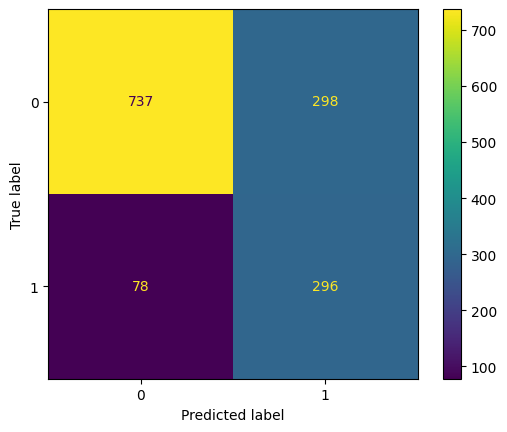

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

## Logistic Regression Insight

Logistic Regression provides a strong baseline with good recall for churn prediction.

Using class_weight='balanced' helped handle class imbalance effectively.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [9]:
print("Random Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

print("AUC Score:", roc_auc_score(y_test, y_prob_rf))

Random Forest Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

AUC Score: 0.8250342297656876


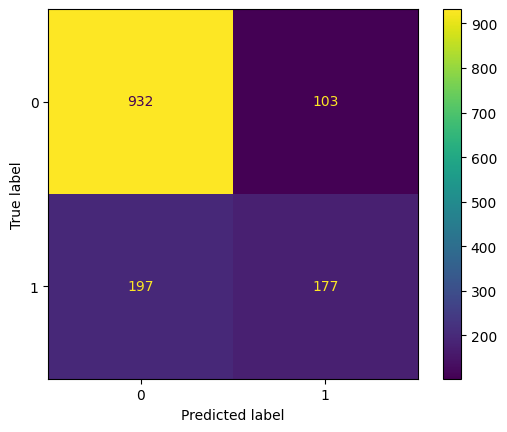

In [10]:
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [12]:
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best_rf))
print("Best RF AUC:", roc_auc_score(y_test, y_prob_best_rf))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

Best RF AUC: 0.840903924152006


## Random Forest Insight

Random Forest improved performance over Logistic Regression by capturing non-linear relationships.

Hyperparameter tuning using GridSearchCV further improved AUC score.

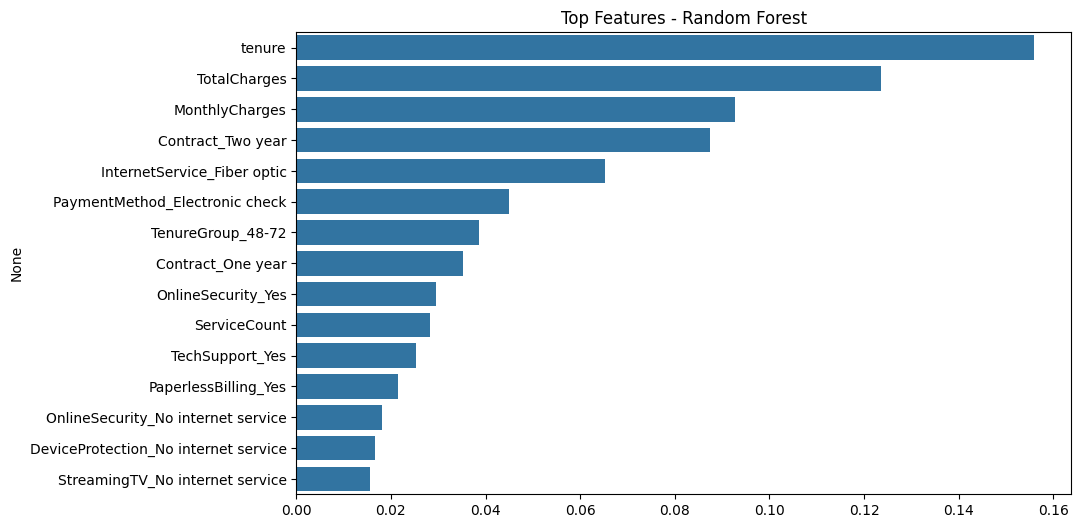

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top Features - Random Forest")
plt.show()

In [14]:
results = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_lr),
    "Random Forest": roc_auc_score(y_test, y_prob_rf),
    "Tuned RF": roc_auc_score(y_test, y_prob_best_rf)
}

results

{'Logistic Regression': 0.8419721511793122,
 'Random Forest': 0.8250342297656876,
 'Tuned RF': 0.840903924152006}

## Model Comparison

Logistic Regression achieved the highest AUC score (~0.842), performing slightly better than Random Forest.

Random Forest did not outperform Logistic Regression in this case, possibly due to limited tuning or dataset characteristics.

Hyperparameter tuning improved Random Forest performance close to Logistic Regression.

This shows that simpler models like Logistic Regression can perform competitively on structured data.

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=2.77,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [16]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

print("XGBoost Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("XGBoost AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Report:

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.81      0.75      0.76      1409

XGBoost AUC: 0.8431475884161307


In [18]:
results = {
    "Logistic Regression": roc_auc_score(y_test, y_prob_lr),
    "Random Forest": roc_auc_score(y_test, y_prob_rf),
    "Tuned RF": roc_auc_score(y_test, y_prob_best_rf),
    "XGBoost": roc_auc_score(y_test, y_prob_xgb)
}

results

{'Logistic Regression': 0.8419721511793122,
 'Random Forest': 0.8250342297656876,
 'Tuned RF': 0.840903924152006,
 'XGBoost': 0.8431475884161307}

## Final Model Comparison

XGBoost achieved the highest AUC score (~0.843), slightly outperforming Logistic Regression (~0.842).

However, the performance difference is minimal, indicating that the dataset is relatively simple and well-structured.

Logistic Regression performs competitively, while XGBoost provides marginal improvement by capturing non-linear relationships.

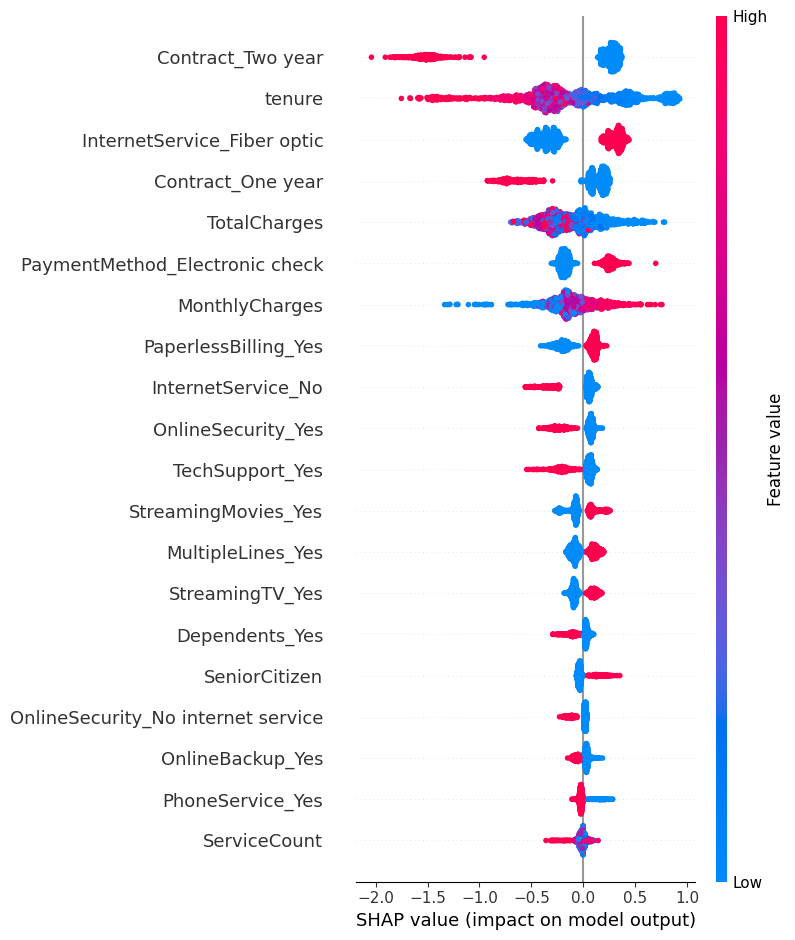

In [19]:
!pip install shap
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

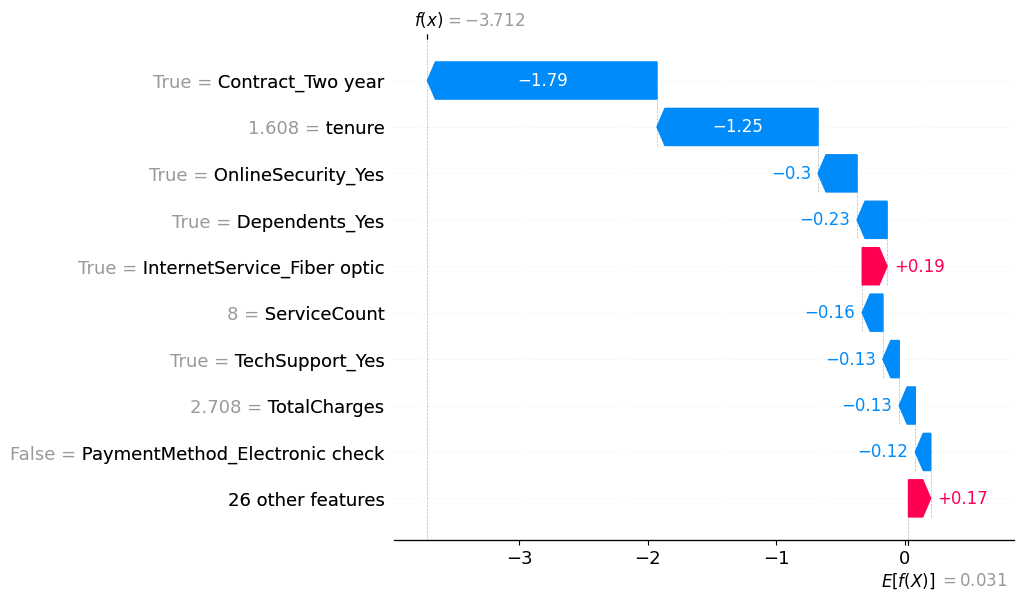

In [20]:
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0]
    )
)

## SHAP Insight

SHAP values help explain individual predictions by showing how each feature contributes to churn probability.

For example, high monthly charges and month-to-month contracts increase churn risk, while long tenure reduces it.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['tenure','MonthlyCharges','TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [22]:
import joblib

joblib.dump(xgb, "../models/xgb_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

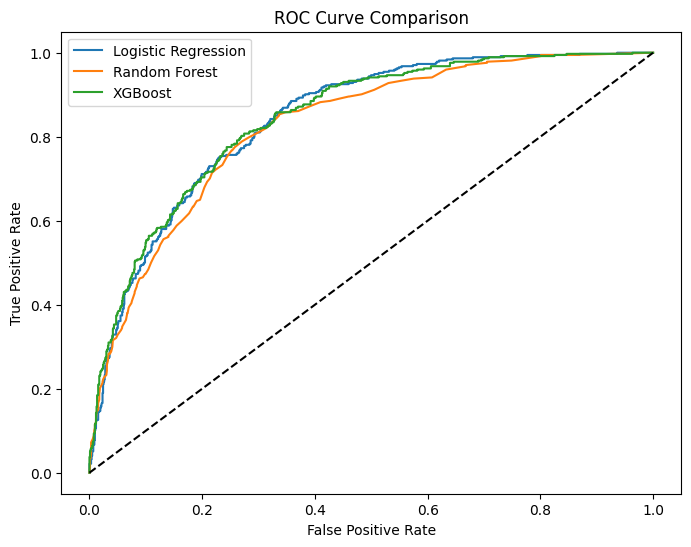

In [23]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1], [0,1], 'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("../outputs/model_comparison.png")
plt.show()

## ROC Curve Insight

The ROC curve shows that all models perform significantly better than random guessing.

XGBoost and Logistic Regression perform similarly, with XGBoost having a slight edge.

## Final Model Selection

XGBoost is selected as the final model due to its slightly higher AUC score.

However, Logistic Regression also performed competitively, indicating that the dataset has relatively linear patterns.

In [24]:
import pandas as pd

pred_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_xgb,
    "Probability": y_prob_xgb
})

pred_df.to_csv("../data/churn_predictions.csv", index=False)


In [25]:
import pandas as pd
import pandas as pd
import joblib

# Load model
xgb = joblib.load("../models/xgb_model.pkl")

# 🔥 Load ORIGINAL dataset (with customerID)
df_original = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Load cleaned dataset (for features)
df_clean = pd.read_csv("../data/clean_df.csv")

# Recreate features on clean data
df_clean['TenureGroup'] = pd.cut(df_clean['tenure'],
                                bins=[0,12,24,48,72],
                                labels=['0-12','12-24','24-48','48-72'])

services = ['PhoneService','MultipleLines','InternetService',
            'OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies']

df_clean['ServiceCount'] = df_clean[services].apply(lambda x: (x == 'Yes').sum(), axis=1)

threshold = df_clean['MonthlyCharges'].quantile(0.65)
df_clean['HighCharges'] = (df_clean['MonthlyCharges'] > threshold).astype(int)

# Encoding
df_encoded_full = pd.get_dummies(df_clean, drop_first=True)

# Align with training
import joblib
X_train = joblib.load("../models/X_train.pkl")
df_encoded_full = df_encoded_full.reindex(columns=X_train.columns, fill_value=0)

X = df_encoded_full

# Predictions
y_prob_full = xgb.predict_proba(X)[:, 1]
y_pred_full = xgb.predict(X)

# 🔥 Merge customerID back
df_final = df_original.copy()

df_final['ChurnProbability'] = y_prob_full
df_final['PredictedChurn'] = y_pred_full

# Save
df_final.to_csv("../data/churn_predictions.csv", index=False)

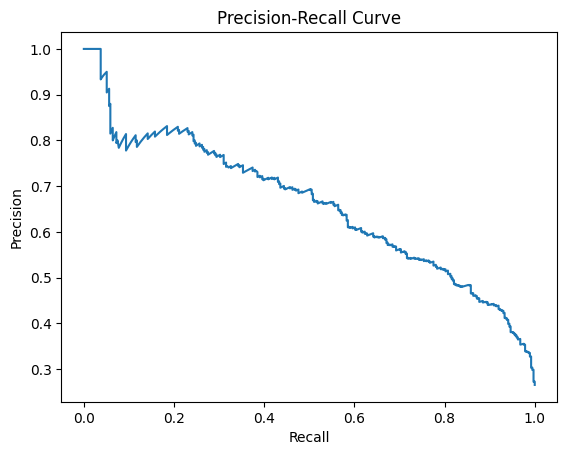

In [26]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Precision-Recall Insight

The model achieves high recall, meaning it effectively identifies customers likely to churn.

This is valuable for business use cases where missing a churn customer is costly.

## Final Project Summary

- Built an end-to-end customer churn prediction system
- Performed data cleaning and handled hidden missing values
- Conducted EDA to extract business insights
- Engineered meaningful features like tenure groups and service count
- Trained multiple models including Logistic Regression, Random Forest, and XGBoost
- Achieved best AUC score of ~0.84 using XGBoost
- Used SHAP for model explainability
- Exported predictions for dashboard integration